In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import time

1) a)

$f(x) = e^{-50\left(x - \tfrac{1}{2}\right)^2}$

$\int_{-\infty}^{\infty} f(x)e^{-ikx}\,dx = \hat{f}(k)$

$\frac{1}{2\pi} \int_{-\infty}^{\infty} \hat{f}(k)e^{ikx}\,dk = f(x)$

$\int_{-\infty}^{\infty} e^{-ax^2 + bx}\,dx 
= e^{\frac{b^2}{4a}} \sqrt{\frac{\pi}{a}}$

Let $y = x - \tfrac{1}{2}$ -> $x = y + \tfrac{1}{2}$

Then $\hat{f}(k) 
= \int_{-\infty}^{\infty} f(x)e^{-ikx}\,dx
= \int_{-\infty}^{\infty} e^{-50y^2} e^{-ik(y + \tfrac{1}{2})}\,dy 
= e^{-ik/2} \int_{-\infty}^{\infty} e^{-50y^2 - iky}\,dy$

So using the Gaussian integral formula:
$\hat{f}(k) = e^{-ik/2} \left( e^{-\frac{k^2}{200}} \sqrt{\frac{\pi}{50}} \right)$

1) b)

In [3]:
def f(x):
    return np.exp(-50*(x-0.5)**2)

#Discrete Fourier Transform
def DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j*np.pi*k*n/N)
    return X

#Inverse Discrete Fourier Transform
def IDFT(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j*np.pi*k*n/N)
    return x / N

#Analytical Fourier Transform
def fhat_analytic(k):
    return np.sqrt(np.pi/50)*np.exp(-k**2/200)*np.exp(-1j*k/2)

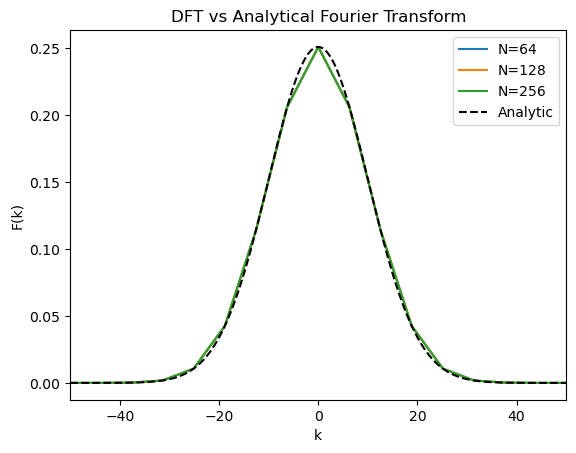

In [4]:
Ns = [64, 128, 256]
x_dense = np.linspace(0, 1, 2000)

plt.figure()

for N in Ns:
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    Xk = DFT(fx) * (1/N)
    
    k = 2*np.pi*np.fft.fftfreq(N, d=1/N)
    idx = np.argsort(k)
    
    plt.plot(k[idx], np.abs(Xk[idx]), label=f"N={N}")
    
k_plot = np.linspace(-50, 50, 1000)
plt.plot(k_plot, np.abs(fhat_analytic(k_plot)), 'k--', label="Analytic")

plt.xlim(-50, 50)
plt.xlabel("k")
plt.ylabel("F(k)")
plt.legend()
plt.title("DFT vs Analytical Fourier Transform")
plt.show()

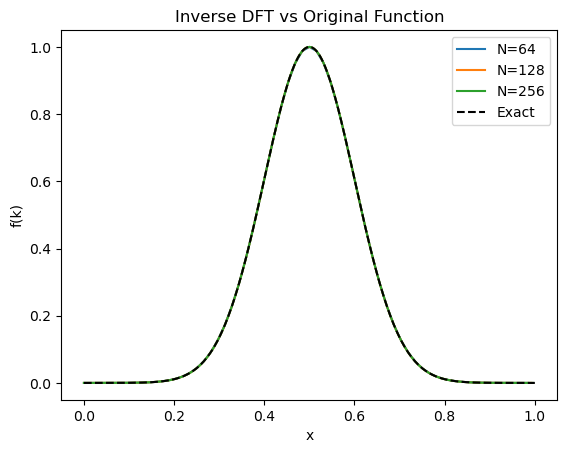

In [5]:
plt.figure()

for N in Ns:
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    fx_rec = IDFT(DFT(fx)).real
    plt.plot(x, fx_rec, label = f"N={N}")

plt.plot(x_dense, f(x_dense), 'k--', label = "Exact")
plt.xlabel("x")
plt.ylabel("f(k)")
plt.legend()
plt.title("Inverse DFT vs Original Function")
plt.show()

1) c)

In [6]:
def time_DFT(N, runs = 100):
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    start = time.time()
    for _ in range(runs):
        DFT(fx)
    return (time.time() - start) / runs

def time_FFT(N, runs = 100):
    x = np.linspace(0, 1, N, endpoint = False)
    fx = f(x)
    start = time.time()
    for _ in range (runs):
        np.fft.fft(fx)
    return (time.time() - start) / runs

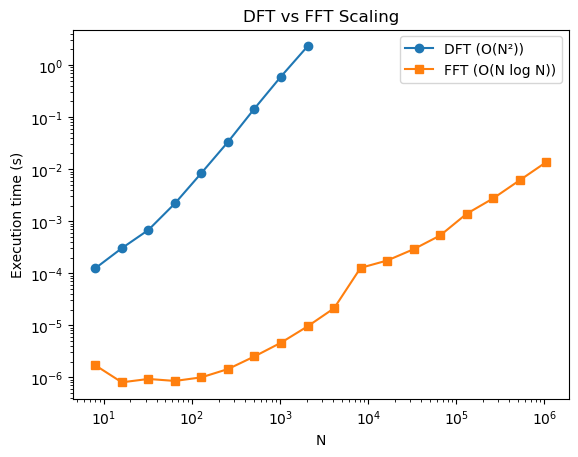

In [43]:
Ns_DFT = [2**j for j in range(3, 12)]
Ns_FFT = [2**j for j in range(3, 21)]

t_DFT = [time_DFT(N) for N in Ns_DFT]
t_FFT = [time_FFT(N) for N in Ns_FFT]

plt.figure()
plt.loglog(Ns_DFT, t_DFT, 'o-', label = "DFT (O(N²))")
plt.loglog(Ns_FFT, t_FFT, 's-', label="FFT (O(N log N))")
plt.xlabel("N")
plt.ylabel("Execution time (s)")
plt.legend()
plt.title("DFT vs FFT Scaling")
plt.show()

As we can see in our plot of DFT vs FFT Scaling, the DFT scales as O(N²) and becomes much slower for larger values of N. This is because of the nested loops. The FFT, on the other hand, scales as O(N log N). We can see that it takes less time than the DFT with large values of N. Thus, the FFT implementation is more efficient than the DFT.

2) a)

In [12]:
N = 256
alpha = 0.005
dt = 0.001
T = 5
steps = int(T / dt)

x = np.linspace(0, 1, N, endpoint = False)
dx = 1 / N

#k-grid
k = 2 * np.pi * np.fft.fftfreq(N, d = dx)

u0 = np.exp(-50 * (x - 0.5) ** 2)
u_hat = DFT(u0)

In [13]:
u_hat_t = u_hat.copy()

u_xt = []
total_heat = []

for _ in range(steps):
    u_hat_t = u_hat_t * np.exp(-alpha * k**2 * dt) #used the exact solution

    u = np.fft.ifft(u_hat_t).real
    u_xt.append(u)

    # Total heat (integral)
    total_heat.append(np.sum(u) * dx)

u_xt = np.array(u_xt)

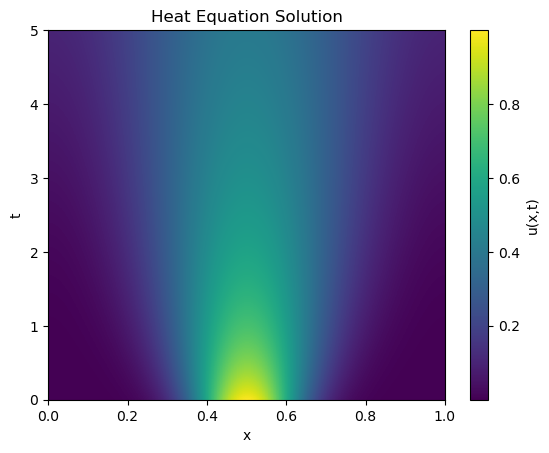

In [14]:
plt.figure()
plt.imshow(
    u_xt,
    extent=[0, 1, 0, T],
    aspect='auto',
    origin='lower'
)
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Heat Equation Solution")
plt.show()

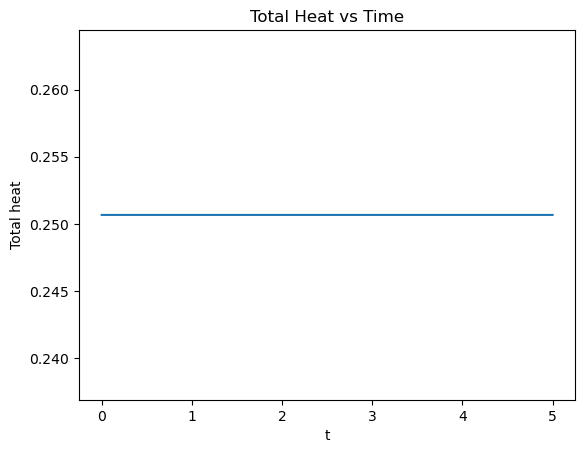

In [15]:
t = np.linspace(0, T, steps)

plt.figure()
plt.plot(t, total_heat)
plt.xlabel("t")
plt.ylabel("Total heat")
plt.title("Total Heat vs Time")
plt.show()

We see from the plot of Total Heat vs Time that the total heat stays constant, as heat is conserved. We see in the Heat Equation Solution plot that the Gaussian spreads out, and the width increases. When trying to calculate these plots, my values kept blowing up, so I had to use the exact solution for each mode in order to calculate them within the parameters given in this problem. 

2) b)

Solution blew up at t = 1.2500 (step 125/500)
Completed 125 steps before blowup


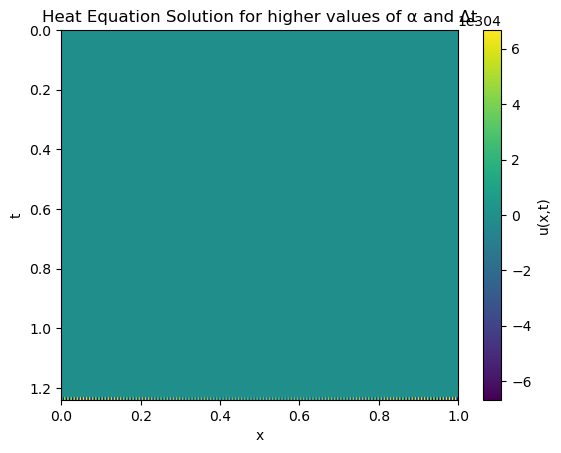

In [25]:
alpha = 0.05
dt = 0.01
T = 5
steps = int(T / dt)

x = np.linspace(0, 1, N, endpoint = False)
dx = 1 / N
#k-grid
k = 2 * np.pi * np.fft.fftfreq(N, d = dx)

u0 = np.exp(-50 * (x - 0.5) ** 2)
u_hat = np.fft.fft(u0)
u_hat_t = u_hat.copy()

u_xt = []
total_heat = []

for i in range(steps):
    with np.errstate(over='ignore', invalid='ignore'):  # suppress warnings — we handle it
        u_hat_t = u_hat_t * (1 - alpha * k**2 * dt)
    
    u = np.fft.ifft(u_hat_t).real

    if not np.all(np.isfinite(u)):
        blowup_step = i
        print(f"Solution blew up at t = {i * dt:.4f} (step {i}/{steps})")
        break

    u_xt.append(u)
    total_heat.append(np.sum(u) * dx)


u_xt = np.array(u_xt)
t_axis = np.arange(len(u_xt)) * dt

print(f"Completed {len(u_xt)} steps before blowup")

plt.figure()
plt.imshow(u_xt, extent=[0, 1, t_axis[-1] if len(t_axis) > 0 else dt, 0],
           aspect='auto', origin='upper')
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Heat Equation Solution for higher values of α and Δt")
plt.show()


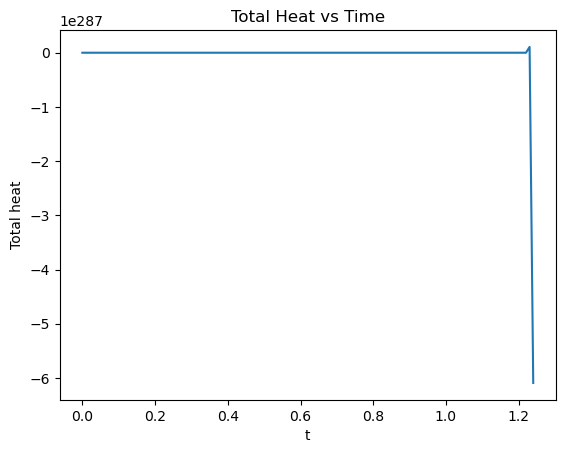

In [23]:
plt.figure()
plt.plot(t_axis, total_heat)
plt.xlabel("t")
plt.ylabel("Total heat")
plt.title("Total Heat vs Time")
plt.show()

When calculating the heat equation solution for higher values of α and Δt, we see that our solutions blow up at t = 1.2500, and we were only able to complete 125 steps before the blowup. This is because of high k values, which blow up first because the k-squared term amplifies the instability. When this happens, the total heat is not conserved and diverges rapidly. A larger value of α means a faster physical diffusion, which places tighter constraints on Δt.